In [1]:
import pennylane as qml
from matplotlib import pyplot as plt
from pennylane import numpy as np

In [4]:
IQubits = 1
PQubits = 2
LQubits = 5
QQubits = 2
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits

In [16]:
dev = qml.device("default.qubit", wires=10, shots=1000)
@qml.qnode(dev)
def OperatorSuperposition(parameters):
    n_params = len(parameters)
    IndexQubits=1
    offset_L = n_params + IndexQubits
    offset_U = n_params + IndexQubits + LQubits
    #for i in range(1):
    #    qml.Hadamard(wires=i)
    #qml.RX(parameters[0], wires=1)
    #qml.RX(parameters[1], wires=2)

    for i in range(LQubits):
        qml.Hadamard(wires=i+offset_L)
    for i in range(LQubits):
        qml.ctrl(
            (
                qml.ctrl(qml.Z(offset_U)@qml.Z(offset_U+1), control=IndexQubits)@
                qml.ctrl(qml.Z(offset_U)@qml.Z(offset_U+1), control=IndexQubits+1)
                @(qml.PauliX(wires=offset_U)@qml.PauliX(wires=offset_U+1))
            )**(2**i), control=offset_U-1-i
        )
    qml.adjoint(qml.QFT(wires=range(offset_L, offset_U)))
                    

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)


/home/gabriel/KIT/PhD/Code/Python/Environments/QPBL/lib/python3.11/site-packages/pennylane/drawer/mpldrawer.py:673: UserWarning: Some control indicators are hidden behind an operator. Consider re-ordering your circuit wires to ensure all control indicators are visible.
  warnings.warn(


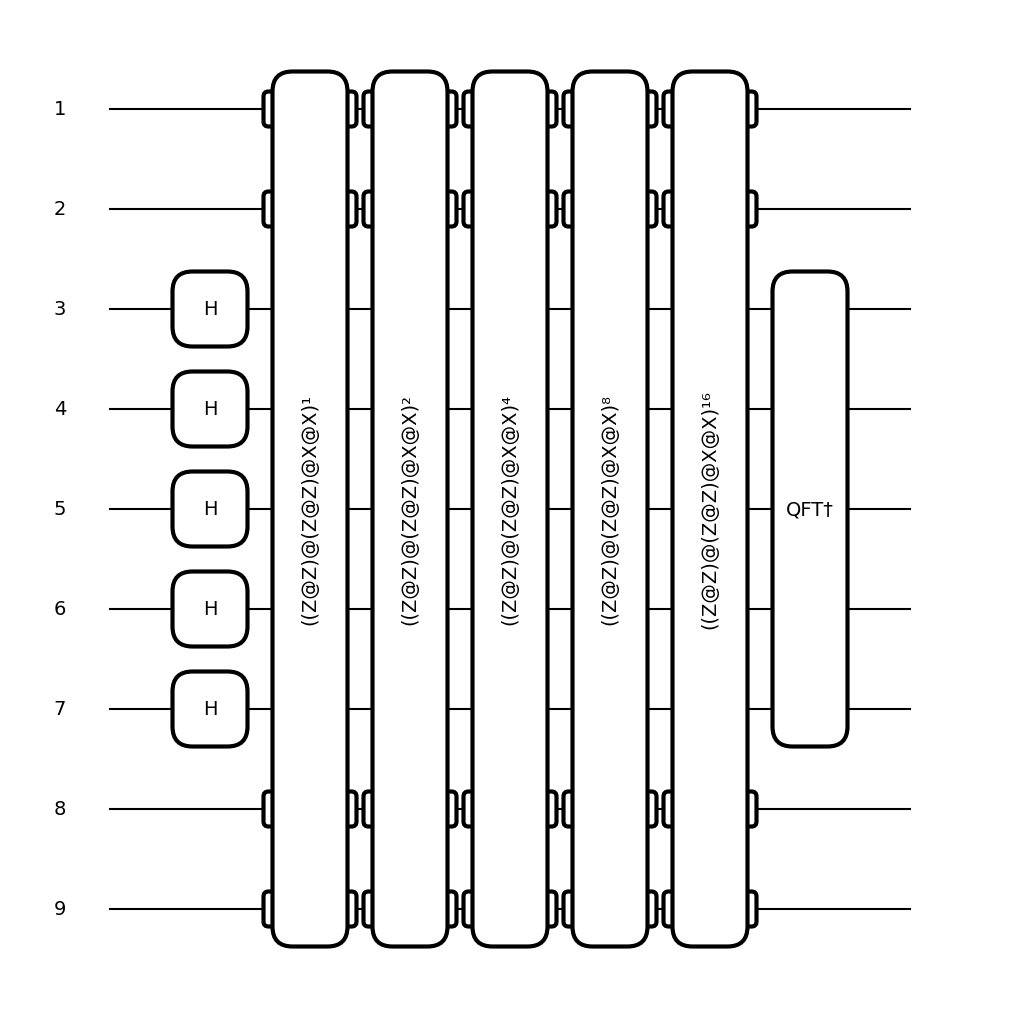

In [17]:
circuit = qml.QNode(OperatorSuperposition, dev)
print(qml.draw_mpl(circuit)([0,0]))